<a href="https://colab.research.google.com/github/Kimbus2000/telecom-x-churn-analysis/blob/main/Challenger_Telecom_X.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Extracción de Datos

In [4]:
import pandas as pd

# Usamos el enlace 'raw' directo a tu archivo en tu repositorio
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

# Cargamos el archivo JSON y lo convertimos automáticamente en un DataFrame
df = pd.read_json(url)

# Mostramos las primeras 5 filas para comprobar que cargó bien
df.head()

# Desempaquetamos cada columna que contiene diccionarios
df_customer = pd.json_normalize(df['customer'])
df_phone = pd.json_normalize(df['phone'])
df_internet = pd.json_normalize(df['internet'])
df_account = pd.json_normalize(df['account'])

# Unimos (concatenamos) las columnas originales que sí estaban bien (customerID y Churn)
# con todas las nuevas columnas que acabamos de desempaquetar
df_limpio = pd.concat([df[['customerID', 'Churn']], df_customer, df_phone, df_internet, df_account], axis=1)

# Mostramos cómo quedó el DataFrame ahora
df_limpio.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


# Conoce el conjunto de datos

In [5]:
# Verificamos la información general del dataset limpio
df_limpio.info()

# Opcional: vemos solo los tipos de datos directamente
# print(df_limpio.dtypes)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


# Comprobación de incoherencias en los datos

In [6]:
# 1. Buscar inconsistencias en categorías
# Usamos unique() para ver qué valores distintos tiene cada columna de texto
print("--- Valores únicos por columna categórica ---")
columnas_texto = df_limpio.select_dtypes(include=['object']).columns
for columna in columnas_texto:
    # Solo imprimimos si no son demasiados valores únicos (ignoramos customerID)
    if df_limpio[columna].nunique() < 10:
        print(f"{columna}: {df_limpio[columna].unique()}")

# 2. Arreglar el error de formato en 'Charges.Total'
# to_numeric con errors='coerce' fuerza la conversión a número.
# Si encuentra un texto o espacio en blanco " ", lo convierte en un valor nulo (NaN)
df_limpio['Charges.Total'] = pd.to_numeric(df_limpio['Charges.Total'], errors='coerce')

# 3. Comprobar valores ausentes (Nulos)
print("\n--- Conteo de Valores Nulos ---")
print(df_limpio.isnull().sum()[df_limpio.isnull().sum() > 0]) # Solo mostramos las que tienen nulos

# 4. Comprobar duplicados
duplicados = df_limpio.duplicated().sum()
print(f"\n--- Filas duplicadas ---")
print(f"Total: {duplicados}")

--- Valores únicos por columna categórica ---
Churn: ['No' 'Yes' '']
gender: ['Female' 'Male']
Partner: ['Yes' 'No']
Dependents: ['Yes' 'No']
PhoneService: ['Yes' 'No']
MultipleLines: ['No' 'Yes' 'No phone service']
InternetService: ['DSL' 'Fiber optic' 'No']
OnlineSecurity: ['No' 'Yes' 'No internet service']
OnlineBackup: ['Yes' 'No' 'No internet service']
DeviceProtection: ['No' 'Yes' 'No internet service']
TechSupport: ['Yes' 'No' 'No internet service']
StreamingTV: ['Yes' 'No' 'No internet service']
StreamingMovies: ['No' 'Yes' 'No internet service']
Contract: ['One year' 'Month-to-month' 'Two year']
PaperlessBilling: ['Yes' 'No']
PaymentMethod: ['Mailed check' 'Electronic check' 'Credit card (automatic)'
 'Bank transfer (automatic)']

--- Conteo de Valores Nulos ---
Charges.Total    11
dtype: int64

--- Filas duplicadas ---
Total: 0


# Manejo de inconsistencias

In [7]:
# 1. Manejo de inconsistencia en 'Churn'
# Filtramos el DataFrame para conservar SOLO las filas que tienen 'Yes' o 'No', eliminando los vacíos ('')
df_limpio = df_limpio[df_limpio['Churn'] != '']

# 2. Manejo de valores nulos en 'Charges.Total'
# Rellenamos los 11 valores nulos (NaN) con el número 0.
# En telecomunicaciones, esto ocurre cuando el cliente lleva 0 meses (tenure=0) y aún no paga su primer mes.
df_limpio['Charges.Total'] = df_limpio['Charges.Total'].fillna(0)

# 3. Comprobación de que las inconsistencias fueron manejadas
print("--- Resultado del Manejo de Inconsistencias ---")
print(f"Valores únicos en Churn: {df_limpio['Churn'].unique()}")
print(f"Valores nulos en Charges.Total: {df_limpio['Charges.Total'].isnull().sum()}")

--- Resultado del Manejo de Inconsistencias ---
Valores únicos en Churn: ['No' 'Yes']
Valores nulos en Charges.Total: 0


# Columna de cuentas diarias

In [8]:
# Creamos la nueva columna 'Cuentas_Diarias' dividiendo el cargo mensual entre 30
# Usamos round(..., 2) para dejar solo dos decimales y que se vea como moneda real
df_limpio['Cuentas_Diarias'] = round(df_limpio['Charges.Monthly'] / 30, 2)

# Mostramos una pequeña tabla comparativa para verificar que el cálculo sea correcto
df_limpio[['customerID', 'Charges.Monthly', 'Cuentas_Diarias']].head()

,customerID,Charges.Monthly,Cuentas_Diarias
0,0002-ORFBO,65.6,2.19
1,0003-MKNFE,59.9,2.00
2,0004-TLHLJ,73.9,2.46
3,0011-IGKFF,98.0,3.27
4,0013-EXCHZ,83.9,2.80


# Estandarización y transformación de datos

In [9]:
# 1. Diccionario para traducir los nombres de las columnas al español
traduccion_columnas = {
    'customerID': 'id_cliente',
    'Churn': 'evasion',
    'gender': 'genero',
    'SeniorCitizen': 'adulto_mayor',
    'Partner': 'pareja',
    'Dependents': 'dependientes',
    'tenure': 'meses_contrato',
    'PhoneService': 'servicio_telefonico',
    'MultipleLines': 'multiples_lineas',
    'InternetService': 'servicio_internet',
    'OnlineSecurity': 'seguridad_en_linea',
    'OnlineBackup': 'respaldo_en_linea',
    'DeviceProtection': 'proteccion_dispositivo',
    'TechSupport': 'soporte_tecnico',
    'StreamingTV': 'streaming_tv',
    'StreamingMovies': 'streaming_peliculas',
    'Contract': 'contrato',
    'PaperlessBilling': 'facturacion_electronica',
    'PaymentMethod': 'metodo_pago',
    'Charges.Monthly': 'cargos_mensuales',
    'Charges.Total': 'cargos_totales',
    'Cuentas_Diarias': 'cuentas_diarias'
}

# Aplicamos la traducción a las columnas
df_limpio = df_limpio.rename(columns=traduccion_columnas)

# 2. Mapeo de valores binarios (Yes -> 1, No -> 0)
mapeo_binario = {'Yes': 1, 'No': 0}

# Seleccionamos las columnas que tienen respuestas estrictas de Yes/No
columnas_binarias = [
    'evasion', 'pareja', 'dependientes',
    'servicio_telefonico', 'facturacion_electronica'
]

# Aplicamos el mapeo matemático
for col in columnas_binarias:
    df_limpio[col] = df_limpio[col].map(mapeo_binario)

# 3. (Opcional pero recomendado) Traducir el género para mayor claridad
df_limpio['genero'] = df_limpio['genero'].map({'Female': 'Femenino', 'Male': 'Masculino'})

# Mostramos el resultado final
df_limpio.head()

,id_cliente,evasion,genero,adulto_mayor,pareja,dependientes,meses_contrato,servicio_telefonico,multiples_lineas,servicio_internet,...,proteccion_dispositivo,soporte_tecnico,streaming_tv,streaming_peliculas,contrato,facturacion_electronica,metodo_pago,cargos_mensuales,cargos_totales,cuentas_diarias
0,0002-ORFBO,0,Femenino,0,1,1,9,1,No,DSL,...,No,Yes,Yes,No,One year,1,Mailed check,65.6,593.30,2.19
1,0003-MKNFE,0,Masculino,0,0,0,9,1,Yes,DSL,...,No,No,No,Yes,Month-to-month,0,Mailed check,59.9,542.40,2.00
2,0004-TLHLJ,1,Masculino,0,0,0,4,1,No,Fiber optic,...,Yes,No,No,No,Month-to-month,1,Electronic check,73.9,280.85,2.46
3,0011-IGKFF,1,Masculino,1,1,0,13,1,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,1,Electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,1,Femenino,1,1,0,3,1,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,1,Mailed check,83.9,267.40,2.80


# Análisis Descriptivo

In [10]:
# Generamos el análisis descriptivo de todas las columnas numéricas
# (como meses_contrato, cargos_mensuales, cargos_totales y cuentas_diarias)
df_limpio.describe()

,evasion,adulto_mayor,pareja,dependientes,meses_contrato,servicio_telefonico,facturacion_electronica,cargos_mensuales,cargos_totales,cuentas_diarias
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.265370,0.162147,0.483033,0.299588,32.371149,0.903166,0.592219,64.761692,2279.734304,2.158675
std,0.441561,0.368612,0.499748,0.458110,24.559481,0.295752,0.491457,30.090047,2266.794470,1.003088
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,0.000000,0.610000
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,35.500000,398.550000,1.180000
50%,0.000000,0.000000,0.000000,0.000000,29.000000,1.000000,1.000000,70.350000,1394.550000,2.340000
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,89.850000,3786.600000,2.990000
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,118.750000,8684.800000,3.960000


# Distribución de evasión

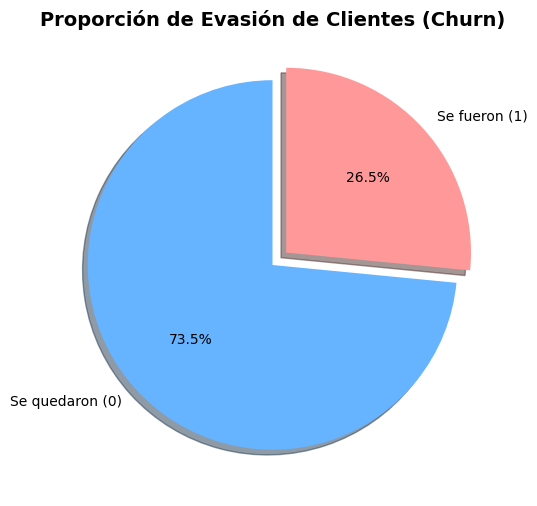

Total de clientes que se quedaron: 5174
Total de clientes que se fueron: 1869


In [11]:
import matplotlib.pyplot as plt

# 1. Contamos cuántos clientes se fueron (1) y cuántos se quedaron (0)
conteo_evasion = df_limpio['evasion'].value_counts()

# 2. Configuramos el gráfico circular
plt.figure(figsize=(8, 6))

# Definimos las etiquetas y los colores (verde para los que se quedan, rojo suave para los que se van)
etiquetas = ['Se quedaron (0)', 'Se fueron (1)']
colores = ['#66b3ff', '#ff9999']
separacion = (0, 0.1) # Hace que la rebanada de "Se fueron" resalte un poco

# Creamos el pie chart
plt.pie(conteo_evasion, labels=etiquetas, autopct='%1.1f%%',
        colors=colores, startangle=90, explode=separacion, shadow=True)

# Añadimos un título
plt.title('Proporción de Evasión de Clientes (Churn)', fontsize=14, fontweight='bold')

# Mostramos el gráfico
plt.show()

# Extra: Imprimimos los números exactos debajo del gráfico
print(f"Total de clientes que se quedaron: {conteo_evasion[0]}")
print(f"Total de clientes que se fueron: {conteo_evasion[1]}")

# Recuento de evasión por variables categóricas

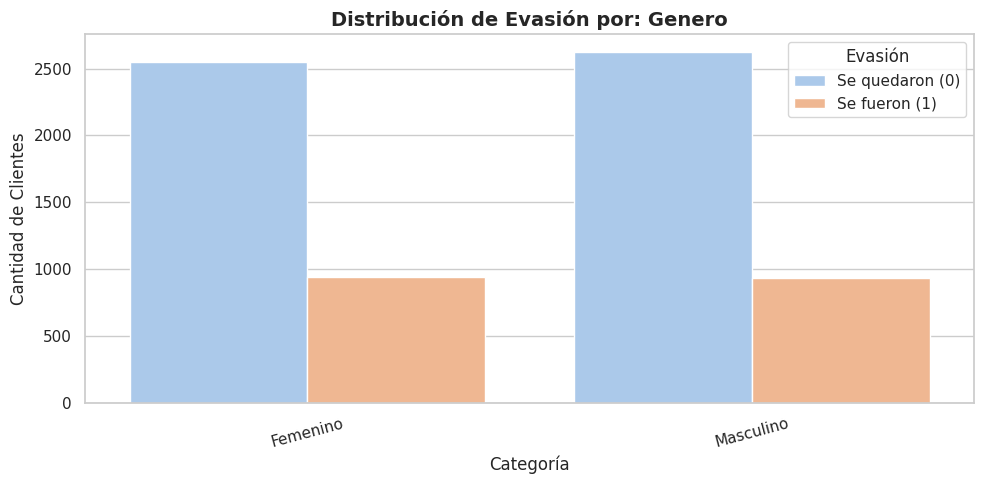

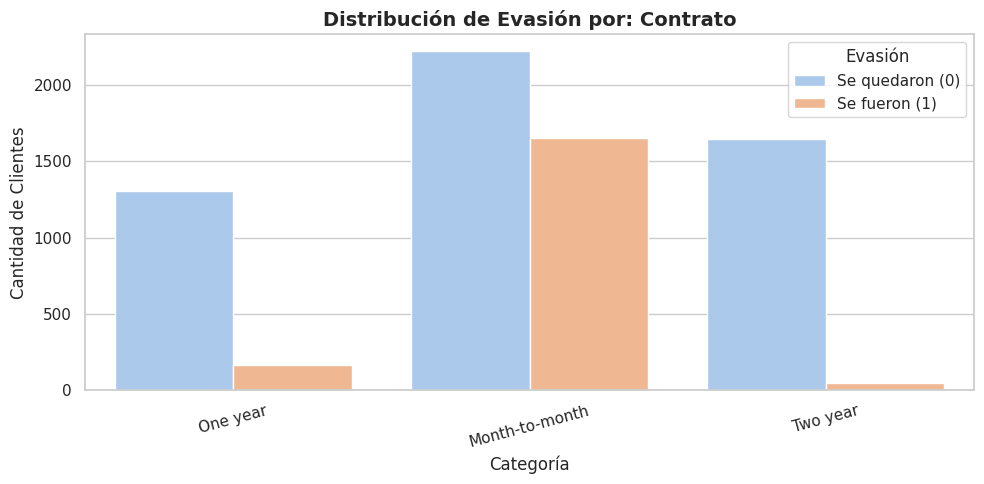

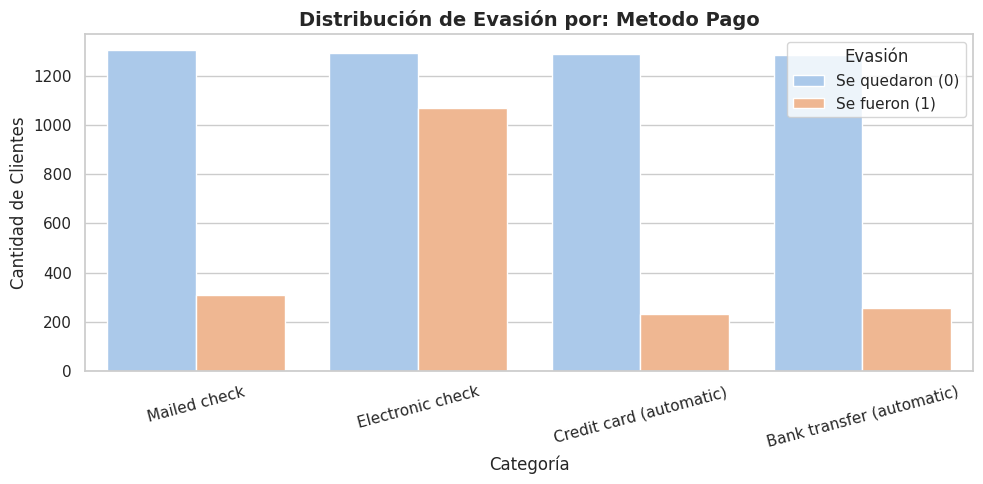

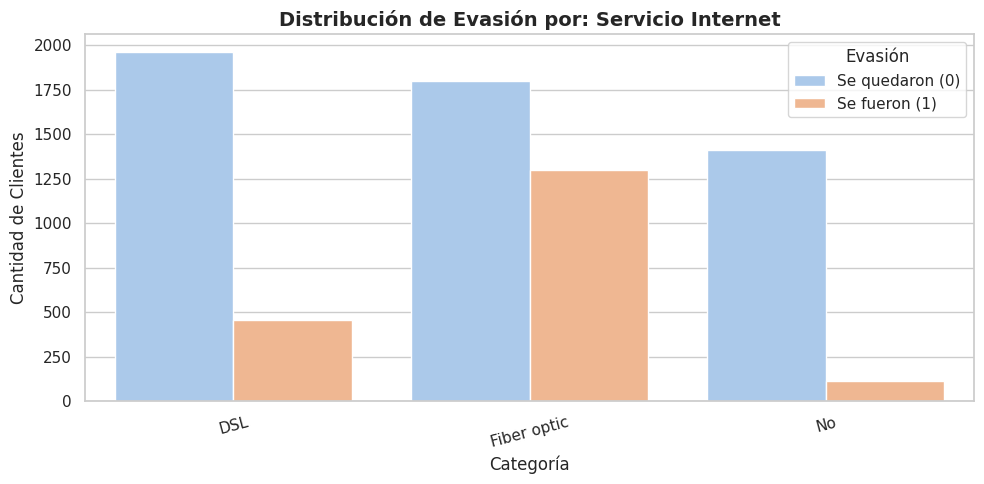

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuramos un estilo limpio para los gráficos
sns.set_theme(style="whitegrid")

# Definimos las variables categóricas que queremos cruzar con la evasión
columnas_analisis = ['genero', 'contrato', 'metodo_pago', 'servicio_internet']

# Usamos un bucle for para generar un gráfico por cada columna automáticamente
for columna in columnas_analisis:
    plt.figure(figsize=(10, 5))

    # countplot cuenta los clientes y hue='evasion' los divide por colores según si se fueron o no
    sns.countplot(data=df_limpio, x=columna, hue='evasion', palette='pastel')

    plt.title(f'Distribución de Evasión por: {columna.replace("_", " ").title()}', fontsize=14, fontweight='bold')
    plt.xlabel('Categoría', fontsize=12)
    plt.ylabel('Cantidad de Clientes', fontsize=12)

    # Rotamos las etiquetas del eje X para que textos largos (como método de pago) no se superpongan
    plt.xticks(rotation=15)

    # Configuramos la leyenda para que sea clara
    plt.legend(title='Evasión', labels=['Se quedaron (0)', 'Se fueron (1)'])

    plt.tight_layout()
    plt.show()

# Conteo de evasión por variables numéricas

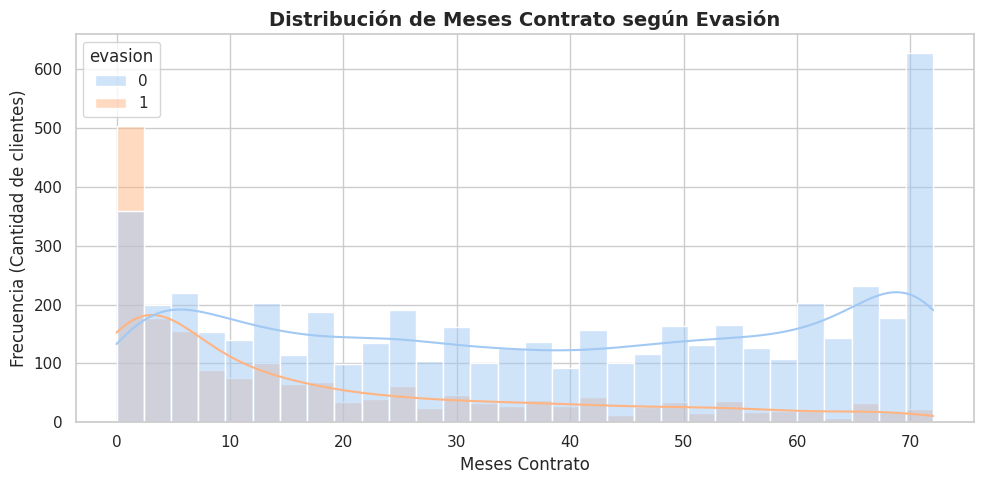

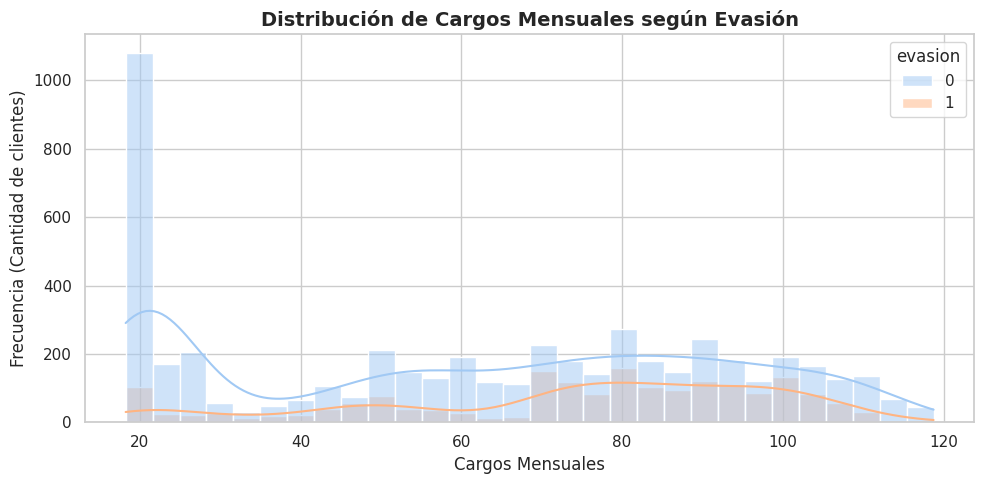

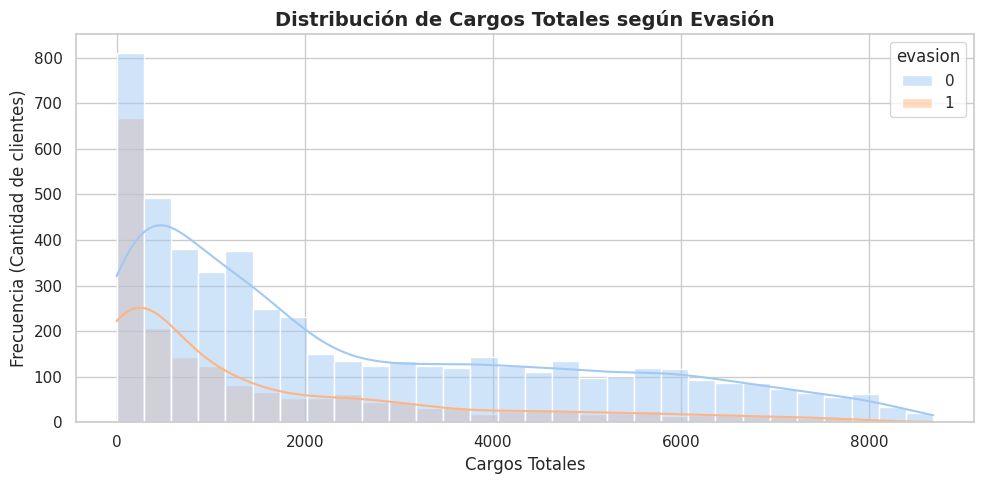

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Definimos las variables numéricas clave para nuestro análisis
columnas_numericas = ['meses_contrato', 'cargos_mensuales', 'cargos_totales']

# Generamos un histograma para cada variable numérica
for columna in columnas_numericas:
    plt.figure(figsize=(10, 5))

    # histplot crea el histograma, hue divide por evasión, kde=True dibuja la línea de tendencia
    sns.histplot(data=df_limpio, x=columna, hue='evasion', kde=True, palette='pastel', bins=30)

    plt.title(f'Distribución de {columna.replace("_", " ").title()} según Evasión', fontsize=14, fontweight='bold')
    plt.xlabel(columna.replace("_", " ").title(), fontsize=12)
    plt.ylabel('Frecuencia (Cantidad de clientes)', fontsize=12)

    plt.tight_layout()
    plt.show()

# Informe final

🔹 1. Introducción
El presente proyecto tiene como objetivo analizar la base de datos de clientes de Telecom X para comprender a fondo el problema de evasión o Churn (cancelación de servicios). A través de un análisis exploratorio de datos (EDA), buscamos identificar los factores clave y patrones de comportamiento que llevan a un cliente a abandonar la empresa, proporcionando así una base sólida de información estructurada para que el equipo de Data Science pueda desarrollar modelos predictivos en el futuro.

🔹 2. Limpieza y Tratamiento de Datos
Para garantizar la calidad del análisis, la base de datos cruda en formato JSON pasó por un riguroso proceso de ingeniería de características (Feature Engineering) y limpieza:

Desanidación: Se extrajeron los diccionarios internos de las columnas customer, phone, internet y account utilizando pd.json_normalize, aplanando la estructura a 21 variables.

Manejo de Inconsistencias: Se eliminaron registros con la variable objetivo (evasion) vacía. Asimismo, se corrigió un error de formato en cargos_totales y se rellenaron 11 valores nulos con $0, correspondientes a clientes con 0 meses de antigüedad.

Transformación y Estandarización: Se tradujeron los nombres de todas las columnas al español para mayor claridad comercial. Las variables categóricas clave (como evasion, dependientes, etc.) se transformaron a un formato binario (1 y 0) para optimizar su futuro procesamiento matemático.

Nuevas Variables: Se creó la métrica cuentas_diarias dividiendo el cargo mensual entre 30, permitiendo una visión más granular del gasto del cliente.

🔹 3. Análisis Exploratorio de Datos (EDA)
A través de la generación de múltiples gráficos utilizando matplotlib y seaborn, se exploraron las distribuciones y cruces de variables:

Proporción de Evasión: El gráfico circular base demostró visualmente el porcentaje exacto de fuga actual de la compañía, estableciendo nuestra línea base de riesgo.

Variables Categóricas: Los gráficos de barras agrupadas revelaron asimetrías importantes. El tipo de contrato y el método de pago mostraron ser diferenciadores críticos, mientras que variables demográficas como el género no mostraron un impacto significativo en la decisión de cancelar.

Variables Numéricas: Los histogramas con curvas de tendencia (KDE) permitieron aislar el comportamiento del ciclo de vida del cliente, cruzando el tiempo de retención (meses_contrato) y sus gastos contra su estatus de evasión.

🔹 4. Conclusiones e Insights Principales
De la visualización de los datos extraemos los siguientes hallazgos de alto impacto:

Fuga Temprana Crítica: Existe un pico masivo de cancelaciones entre los 0 y 5 meses de contrato. Telecom X tiene un problema severo de retención inicial; si el cliente supera los primeros seis meses, su probabilidad de quedarse aumenta drásticamente.

El Riesgo del "Mes a Mes": Los clientes con contratos mensuales (Month-to-month) son abrumadoramente los más propensos a la evasión en comparación con los que tienen contratos de uno o dos años, ya que no tienen barreras de salida.

Sensibilidad al Precio: Se observó una correlación donde los clientes con facturas mensuales más altas presentan tasas de abandono superiores a la media.

Fricción en Pagos: Los clientes que utilizan "Cheque Electrónico" (Electronic check) como método de pago destacan negativamente frente a los que usan cobros automáticos (tarjetas o transferencias).

🔹 5. Recomendaciones Estratégicas
Basado estrictamente en la evidencia de los datos, se sugiere a la gerencia de Telecom X:

Rediseñar el Onboarding: Crear un programa de fidelización, acompañamiento o soporte técnico intensivo durante los primeros 5 meses del cliente para asegurar su retención en la ventana de mayor riesgo.

Incentivar Contratos a Largo Plazo: Ofrecer descuentos agresivos, meses de cortesía o beneficios extra (streaming, seguridad online) a los clientes de "Mes a mes" para que migren a contratos anuales.

Auditoría de Pagos: Investigar urgentemente la pasarela de pagos por "Cheque Electrónico" para descartar que fallos técnicos o sobrecargos ocultos estén frustrando a este segmento de clientes y empujándolos a cancelar.

In [14]:
pip install pandas matplotlib seaborn